In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 
from Triangle.Cosmology import LuminosityDistance

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")
    
np.random.seed(114514)

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


No pyseobnr.
no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Parameters 

In [2]:
# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(4.5, 7.5)), 
    'mass_ratio': np.random.uniform(0.1, 0.99), 
    'spin_1z': np.random.uniform(-0.9, 0.9),
    'spin_2z': np.random.uniform(-0.9, 0.9),
    'reference_time': np.random.uniform(30., 365.), # the data duration will be 30 days 
    'reference_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(np.log10(LuminosityDistance(1.)/MPC), np.log10(LuminosityDistance(15.)/MPC))), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(0, TWOPI), # [rad]
    'latitude': np.arcsin(np.random.uniform(-1., 1.)), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 3658201.48739845,
 'mass_ratio': 0.7017939174280188,
 'spin_1z': -0.13209939443812901,
 'spin_2z': 0.5094582566568905,
 'reference_time': 294.1055942241633,
 'reference_phase': 0.22723542654969606,
 'luminosity_distance': 120443.8681924542,
 'inclination': 1.0242620672883695,
 'longitude': 1.3208186729980294,
 'latitude': 0.34319743322074053,
 'psi': 0.4614176140098712}

## Data settings 

In [3]:
Tobs = 30. * DAY 
t_start = (mbhb_parameters["reference_time"] + 3.) * DAY - Tobs # the reference time of waveform is set to 3 days before end 
t_end = t_start + Tobs
dt = 1. 
fsample = 1. / dt # sampling rate in Hz 

data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 100): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*1e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape


(1192298,)

## Models 

In [4]:
ORBIT_DIR = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"
orbit = Orbit(
    OrbitDir=ORBIT_DIR, 
) 

# initialize  waveform generator 
WFG_HM = WaveformGeneratorFRef(
    mode="full", 
)

# initialize response generator 
FDTDI_HM = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG_HM, 
)

# response settings 
response_kwargs_HM = dict(
    fmin=data_frequencies[1], 
    fmax=data_frequencies[-1], 
    fref=1e-3, # will be modified to merger frequency later 
    modes=[(2, 2), (3, 3), (4, 4), (2, 1)], 
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tref_at_constellation=True, 
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method="cubic", 
)

fgrids, amps_out, phas_out, tfs_out = WFG_HM(
    parameters=mbhb_parameters, 
    Nfreqs=1024, 
    fmin=response_kwargs_HM["fmin"], 
    fmax=response_kwargs_HM["fmax"], 
    fref=response_kwargs_HM["fref"],
    freqs=data_frequencies, 
    )
coal_idx = np.argmax(amps_out[(2,2)][0] * fgrids[0] ** 2)
coal_freq = fgrids[0][coal_idx]
response_kwargs_HM["fref"] = coal_freq
response_kwargs_HM_like = response_kwargs_HM.copy() 
response_kwargs_HM_like["interpolation_method"] = None 
print("merger frequency =", coal_freq)

merger frequency = 0.001935185185185185


In [5]:
PSDfunc = TDIPSDs()
PSD_channels = np.array([
    PSDfunc.PSD_A2(data_frequencies), 
    PSDfunc.PSD_A2(data_frequencies), 
])

# covariance matrix 
CovMat = np.array([
    [PSD_channels[0], np.zeros_like(PSD_channels[0])],
    [np.zeros_like(PSD_channels[0]), PSD_channels[1]],
]) / 4. / delta_f 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

PSD_channels.shape, InvCovMat.shape 

((2, 1192298), (1192298, 2, 2))

## Data generation 

In [6]:
wf_channels = FDTDI_HM.Response(mbhb_parameters, data_frequencies, **response_kwargs_HM)

# generate frequency-domain noises 
Re_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
Im_tmp = np.random.normal(scale=np.sqrt(PSD_channels / 4. / delta_f))
noise_channels = xp.array(Re_tmp + 1.j * Im_tmp) 

# combine signal and noise 
data_channels = wf_channels + noise_channels 
# data_channels = wf_channels.copy()

opt_SNR = FrequencyDomainCovarianceSNR(wf_channels, InvCovMat)

print("source parameters:")
for k, v in mbhb_parameters.items():
    print(k, ":", v)
print("optimal SNR:", opt_SNR)

wf_channels.shape, data_channels.shape

source parameters:
chirp_mass : 3658201.48739845
mass_ratio : 0.7017939174280188
spin_1z : -0.13209939443812901
spin_2z : 0.5094582566568905
reference_time : 294.1055942241633
reference_phase : 0.22723542654969606
luminosity_distance : 120443.8681924542
inclination : 1.0242620672883695
longitude : 1.3208186729980294
latitude : 0.34319743322074053
psi : 0.4614176140098712
optimal SNR: 400.1277160337481


((2, 1192298), (2, 1192298))

(1e-22, 7.449399649161132e-15)

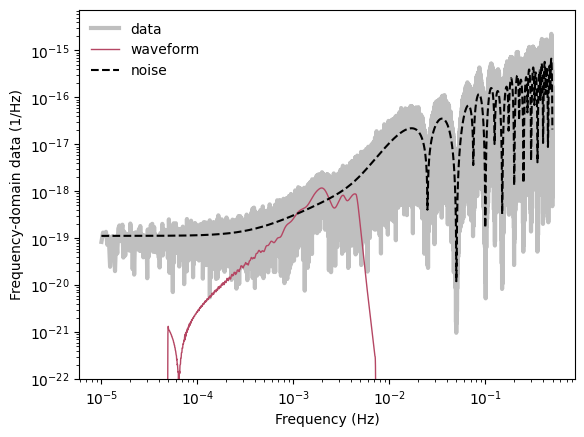

In [7]:
plt.loglog(data_frequencies, np.abs(data_channels[0]), linewidth=3, color="grey", label="data", alpha=0.5)
plt.loglog(data_frequencies, np.abs(wf_channels[0]), linewidth=1, color=RED, label="waveform")
plt.loglog(data_frequencies, np.sqrt(PSD_channels[0] * Tobs / 2.), color="k", linestyle="--", label="noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency-domain data (1/Hz)")
plt.legend(loc="upper left", frameon=False)
plt.ylim(1e-22,)

## Fisher analysis 

In [8]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI_HM.Response(
        parameters=param_dict, 
        freqs=np.array(frequencies),  
        **response_kwargs_HM, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.1,
    'spin_2z': 0.1,
    'reference_time': 0.001,
    'reference_phase': 0.1,
    'luminosity_distance': 10.,
    'inclination': 0.1,
    'longitude': 0.1,
    'latitude': 0.1,
    'psi': 0.1
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=mbhb_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequencies, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 6728.3381690399265,
 'mass_ratio': 0.00327946275258215,
 'spin_1z': 0.016253888865968548,
 'spin_2z': 0.023003930561560932,
 'reference_time': 2.225799464677395e-05,
 'reference_phase': 0.00836165109245377,
 'luminosity_distance': 1193.314031330204,
 'inclination': 0.00818157471515723,
 'longitude': 0.002100785736888155,
 'latitude': 0.002110609175885123,
 'psi': 0.005233016484100058}

## Likelihood

In [9]:
# initialize heterodyned likelihood 
Like = HMLikelihood(
    response_generator=FDTDI_HM, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_HM_like, 
    Fref_waveform=True, 
    use_gpu=False,
)
Like.prepare_het_log_like(base_parameters=mbhb_parameters, num_het_frequency=128)

# use full likelihood as comparison 
Like_full = Likelihood(
    response_generator=FDTDI_HM, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_HM, 
    Fref_waveform=True, 
    use_gpu=False,
)

In [10]:
import bilby 
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="heterodyned"):
        """ 
            type can be "heterodyned" or "full"
        """
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        self.like_type = type 

    def log_likelihood(self):
        if self.like_type == "heterodyned": 
            return Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))
        else: 
            return Like.full_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))

## Prior 

In [11]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=mbhb_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=mbhb_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, mbhb_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, mbhb_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, mbhb_parameters["spin_1z"]-10.*FIM.param_errors["spin_1z"]), maximum=min(0.9, mbhb_parameters["spin_1z"]+10.*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, mbhb_parameters["spin_2z"]-10.*FIM.param_errors["spin_2z"]), maximum=min(0.9, mbhb_parameters["spin_2z"]+10.*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=mbhb_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=mbhb_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(LuminosityDistance(1.)/MPC, mbhb_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(LuminosityDistance(15.)/MPC, mbhb_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=3590918.1057080505, maximum=3725484.869088849, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.6689992899021973, maximum=0.7345885449538403, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=-0.2946382830978145, maximum=0.03043949422155645, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=0.27941895104128117, maximum=0.7394975622724997, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=294.10537164421686, maximum=294.1058168041098, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=108510.72787915217, maximum=13237

## Run nested sampling 

In [ ]:
from datetime import datetime
nlive = 500

BLike = bilby_likelihood_wrapper()

ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

timestamp = datetime.now().strftime("%y%m%d%H")

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=nlive, 
    stopping=0.1, 
    npool=ncpu, # use all cpus 
    injection_parameters=mbhb_parameters, 
    outdir="Samples",
    label=f"mbhb_{timestamp}",
    plot=True,
    resume=False, 
    allow_multi_valued_likelihood=True,
)

13:11 bilby INFO    : Running for label 'mbhb_26060813', output will be saved to 'Samples'


number of cpus = 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
13:11 bilby INFO    : Analysis priors:
13:11 bilby INFO    : chirp_mass=Uniform(minimum=3590918.1057080505, maximum=3725484.869088849, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
13:11 bilby INFO    : mass_ratio=Uniform(minimum=0.6689992899021973, maximum=0.7345885449538403, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
13:11 bilby INFO    : spin_1z=Uniform(minimum=-0.2946382830978145, maximum=0.03043949422155645, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
13:11 bilby INFO    : spin_2z=Uniform(minimum=0.27941895104128117, maximum=0.7394975622724997, name='spin_2z', latex_

06-08 13:11 nessai INFO    : Running Nessai version 0.14.0.post0
06-08 13:11 nessai INFO    : Starting multiprocessing pool with 12 processes


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


06-08 13:11 nessai INFO    : Initialising nested sampler
06-08 13:11 nessai WARNING : Multi-valued likelihood is allowed. This may lead to slow sampling and strange results.
06-08 13:11 nessai WARNING : Multiprocessing pool has already been configured.
06-08 13:11 nessai WARNING : Removing unused keyword arguments ({'n_steps', 'step_type', 'enforce_likelihood_threshold', 'augment_dims', 'plot_history', 'marginalise_augment', 'ensemble_fraction', 'plot_chain', 'n_accept', 'generate_augment', 'step_kwargs', 'n_marg', 'max_n_clusters'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
06-08 13:11 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'r

In [ ]:
result.plot_corner(save=True)

## Compare Fisher vs Posterior 

Sampled parameters (7): ['reference_time', 'reference_phase', 'luminosity_distance', 'inclination', 'longitude', 'latitude', 'psi']
Fixed/excluded: ['chirp_mass', 'mass_ratio', 'spin_1z', 'spin_2z']


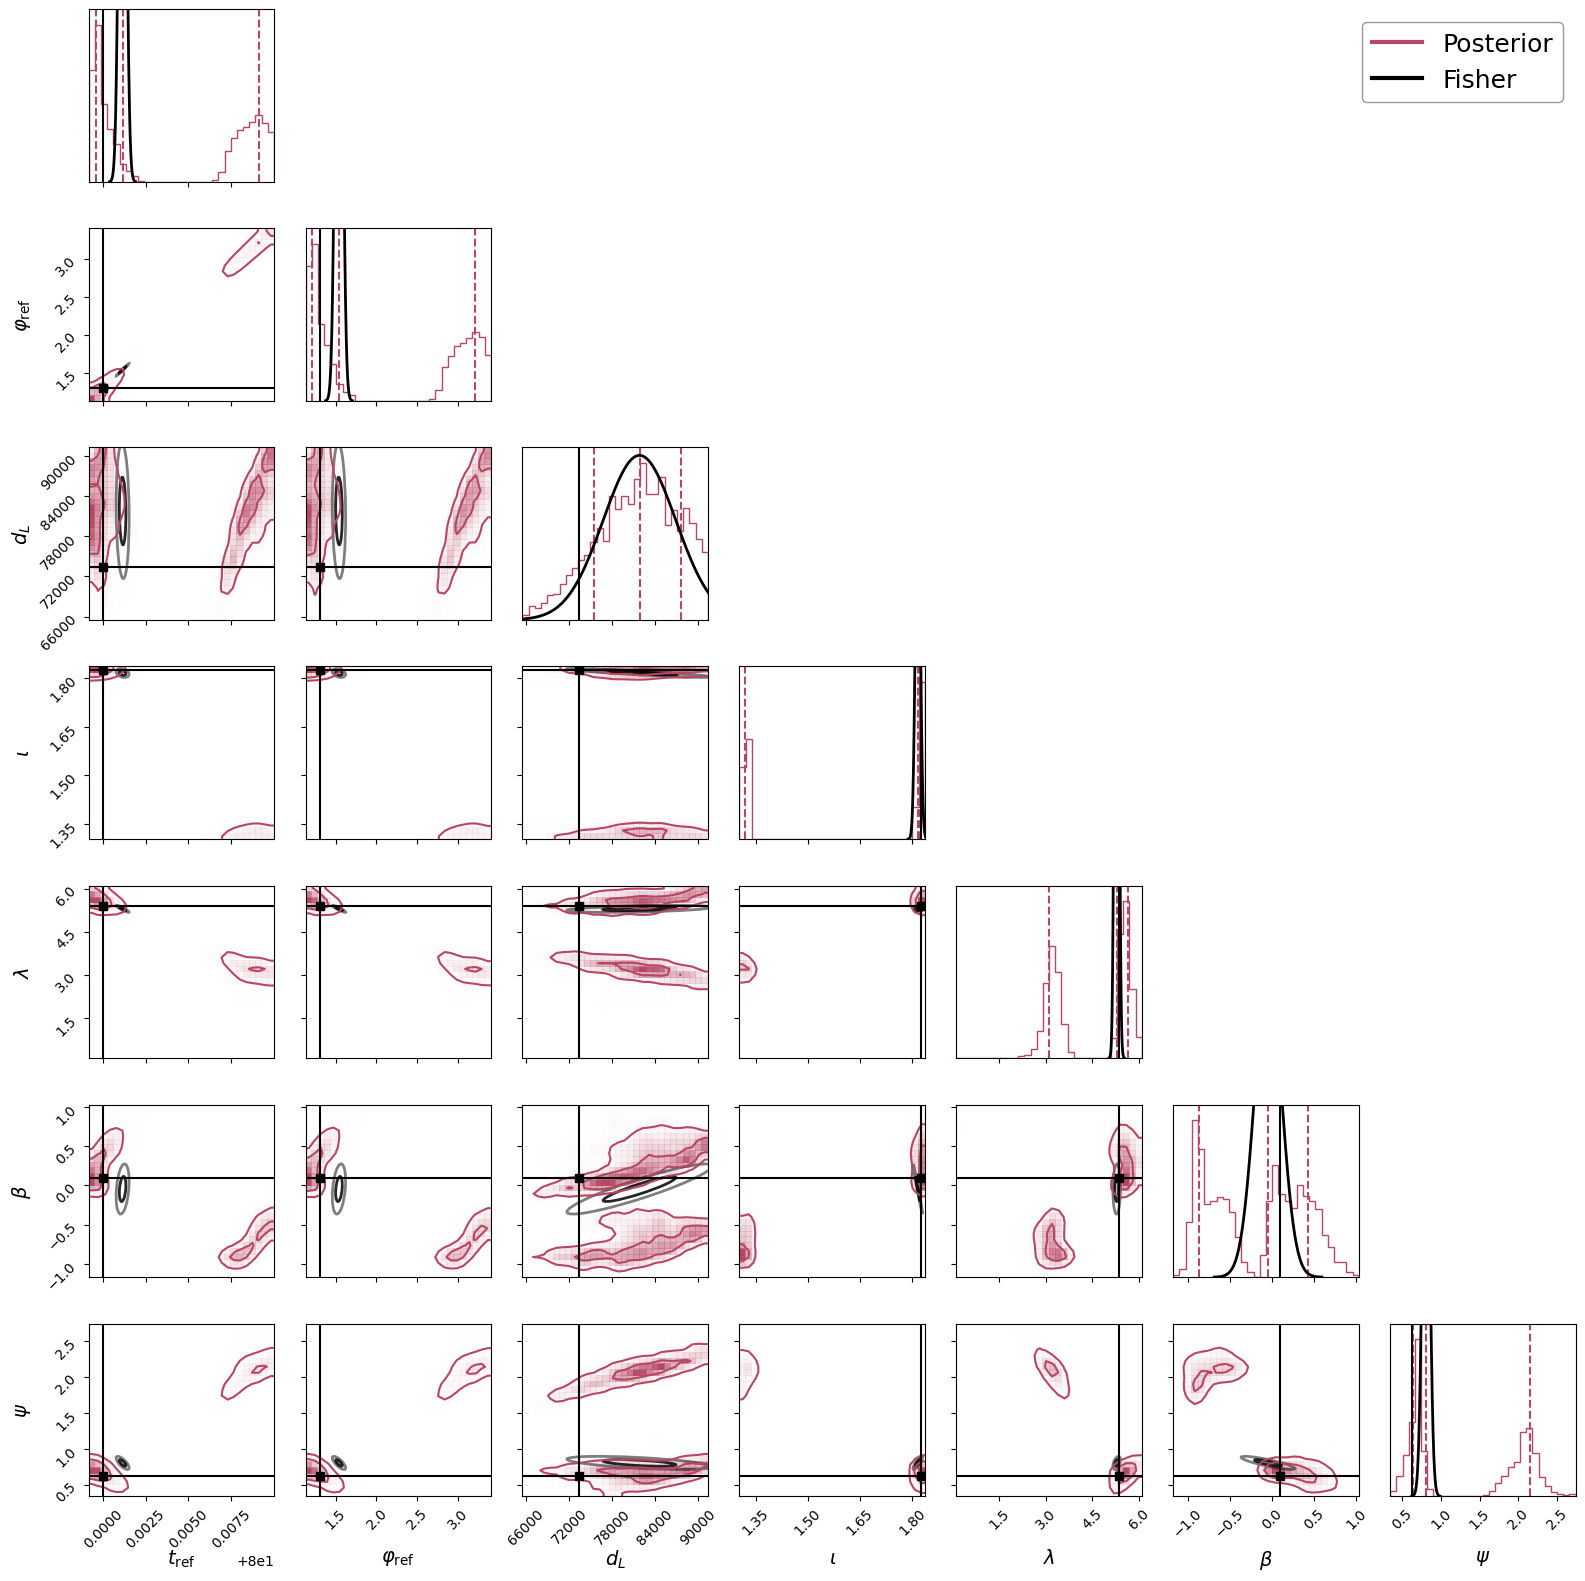


Parameter                    True   Fisher σ   Post. median    Post. σ
-------------------------------------------------------------------------------------
reference_time                 80    0.00019             80    0.00437
reference_phase             1.303     0.0408          1.541      0.919
luminosity_distance     7.341e+04   5.07e+03      8.182e+04   5.68e+03
inclination                 1.825     0.0069          1.816       0.25
longitude                   5.381     0.0605          5.294       1.21
latitude                   0.0901       0.16       -0.04611      0.559
psi                        0.6253     0.0456         0.8057      0.722


In [ ]:
# ===== Posterior + Fisher comparison =====
import corner
from scipy.stats import norm
from matplotlib.patches import Ellipse

# Extract posterior samples from nessai result
posterior_samples = result.posterior

# Keep only parameters shared with mbhb_parameters (exclude log_likelihood, log_prior, etc.)
param_names_all = [n for n in posterior_samples.keys() if n in mbhb_parameters]

# Filter fixed params: corner checks min==max for no dynamic range; use ptp here
param_names = [n for n in param_names_all if np.ptp(posterior_samples[n]) > 0]

# Only keep parameters also present in Fisher matrix
param_names = [n for n in param_names if n in FIM.param_errors]

fixed_params = [n for n in param_names_all if n not in param_names]
print(f"Sampled parameters ({len(param_names)}): {param_names}")
print(f"Fixed/excluded: {fixed_params}")

# Fisher mean = truth
fisher_mean = np.array([mbhb_parameters[name] for name in param_names])

# Posterior median (used to align Fisher ellipse centers)
posterior_median = np.array([np.median(posterior_samples[n]) for n in param_names])

# Fisher covariance = inverse of Fisher matrix, subset to sampled parameters
fim_param_order = list(FIM.param_errors.keys())
fisher_cov_full = np.linalg.inv(FIM.Fisher)
idx_map = [fim_param_order.index(name) for name in param_names]
fisher_cov = fisher_cov_full[np.ix_(idx_map, idx_map)]
fisher_std = np.sqrt(np.diag(fisher_cov))

# LaTeX labels
latex_labels = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "spin_1z": r"$\chi_{1z}$",
    "spin_2z": r"$\chi_{2z}$",
    "reference_time": r"$t_\mathrm{ref}$",
    "reference_phase": r"$\varphi_\mathrm{ref}$",
    "luminosity_distance": r"$d_L$",
    "inclination": r"$\iota$",
    "longitude": r"$\lambda$",
    "latitude": r"$\beta$",
    "psi": r"$\psi$",
}
param_labels = [latex_labels[n] for n in param_names]

# ---- Plot corner + Fisher overlay ----
fig = corner.corner(
    posterior_samples[param_names].values,
    labels=param_labels,
    truths=fisher_mean,
    truth_color="k",
    quantiles=[0.16, 0.5, 0.84],
    color=RED,
    label_kwargs={"fontsize": 14},
    hist_kwargs={"density": True},
    plot_density=True,
    plot_datapoints=False,
    fill_contours=False,
    levels=(1 - np.exp(-(np.array([1, 2]) ** 2) / 2.)),  # 1σ, 2σ
    smooth=0.9,
    bins=30,
)

axes = np.array(fig.axes).reshape((len(param_names), len(param_names)))

# Enlarge tick labels
for ax in axes.flatten():
    ax.tick_params(labelsize=10)

# ---- Overlay Fisher Gaussian (diagonal) and ellipses (off-diagonal) ----
for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax = axes[i, j]
        if i == j:
            # Diagonal: Fisher Gaussian PDF, centered at posterior median
            sigma_i = fisher_std[i]
            x = np.linspace(
                posterior_median[i] - 4 * sigma_i,
                posterior_median[i] + 4 * sigma_i,
                200,
            )
            ax.plot(
                x,
                norm.pdf(x, posterior_median[i], sigma_i),
                color="k",
                linewidth=2,
                label="Fisher" if i == 0 else "",
            )
        elif i > j:
            # Off-diagonal: Fisher 1σ & 2σ ellipses
            idx = [j, i]  # corner uses (col, row) = (x, y)
            sub_mean = posterior_median[idx]
            sub_cov = fisher_cov[np.ix_(idx, idx)]

            eigenvalues, eigenvectors = np.linalg.eigh(sub_cov)
            angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

            for n_sigma, ls, alpha_val in [(1, "-", 0.85), (2, "-", 0.5)]:
                width, height = 2.0 * n_sigma * np.sqrt(eigenvalues)
                ellipse = Ellipse(
                    xy=sub_mean,
                    width=width,
                    height=height,
                    angle=angle,
                    edgecolor="k",
                    facecolor="none",
                    linewidth=2,
                    linestyle=ls,
                    alpha=alpha_val,
                )
                ax.add_patch(ellipse)

# ---- Legend ----
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=RED, linewidth=3, label="Posterior"),
    Line2D([0], [0], color="k", linewidth=3, label="Fisher"),
]
axes[0, -1].legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=18,
    frameon=True,
    facecolor="white",
    edgecolor="grey",
)

plt.tight_layout()
plt.show()

# ---- Numerical comparison table ----
print("\n" + "=" * 85)
print(f"{'Parameter':<20s} {'True':>12s} {'Fisher σ':>10s} {'Post. median':>14s} {'Post. σ':>10s}")
print("-" * 85)
for i, name in enumerate(param_names):
    post_std = np.std(posterior_samples[name])
    print(
        f"{name:<20s} {fisher_mean[i]:>12.4g} {fisher_std[i]:>10.3g} "
        f"{posterior_median[i]:>14.4g} {post_std:>10.3g}"
    )
print("=" * 85)


constellation 样本总数: 4553, phi_ref < 2.5: 2674

Param                    True      SSB σ     Cstl σ    σ ratio
-----------------------------------------------------------------------------------------------
chirp_mass              1e+07   9.41e+03   8.68e+03       0.92
mass_ratio             0.8222    0.00173    0.00174       1.01
spin_1z                 0.648     0.0109     0.0107       0.98
spin_2z               -0.2626     0.0127     0.0135       1.06
reference_time             80   0.000646   3.45e-05       0.05
reference_phase         1.303      0.136      0.119       0.88
luminosity_distance    7.341e+04   6.04e+03   5.18e+03       0.86
inclination             1.825    0.00383    0.00243       0.63
longitude               5.381       0.33       0.21       0.64
latitude               0.0901      0.261      0.221       0.85
psi                    0.6253      0.111     0.0966       0.87
σ ratio > 1 → constellation 设置下约束更弱
constellation 已过滤 phi_ref < 2.5，仅保留主峰


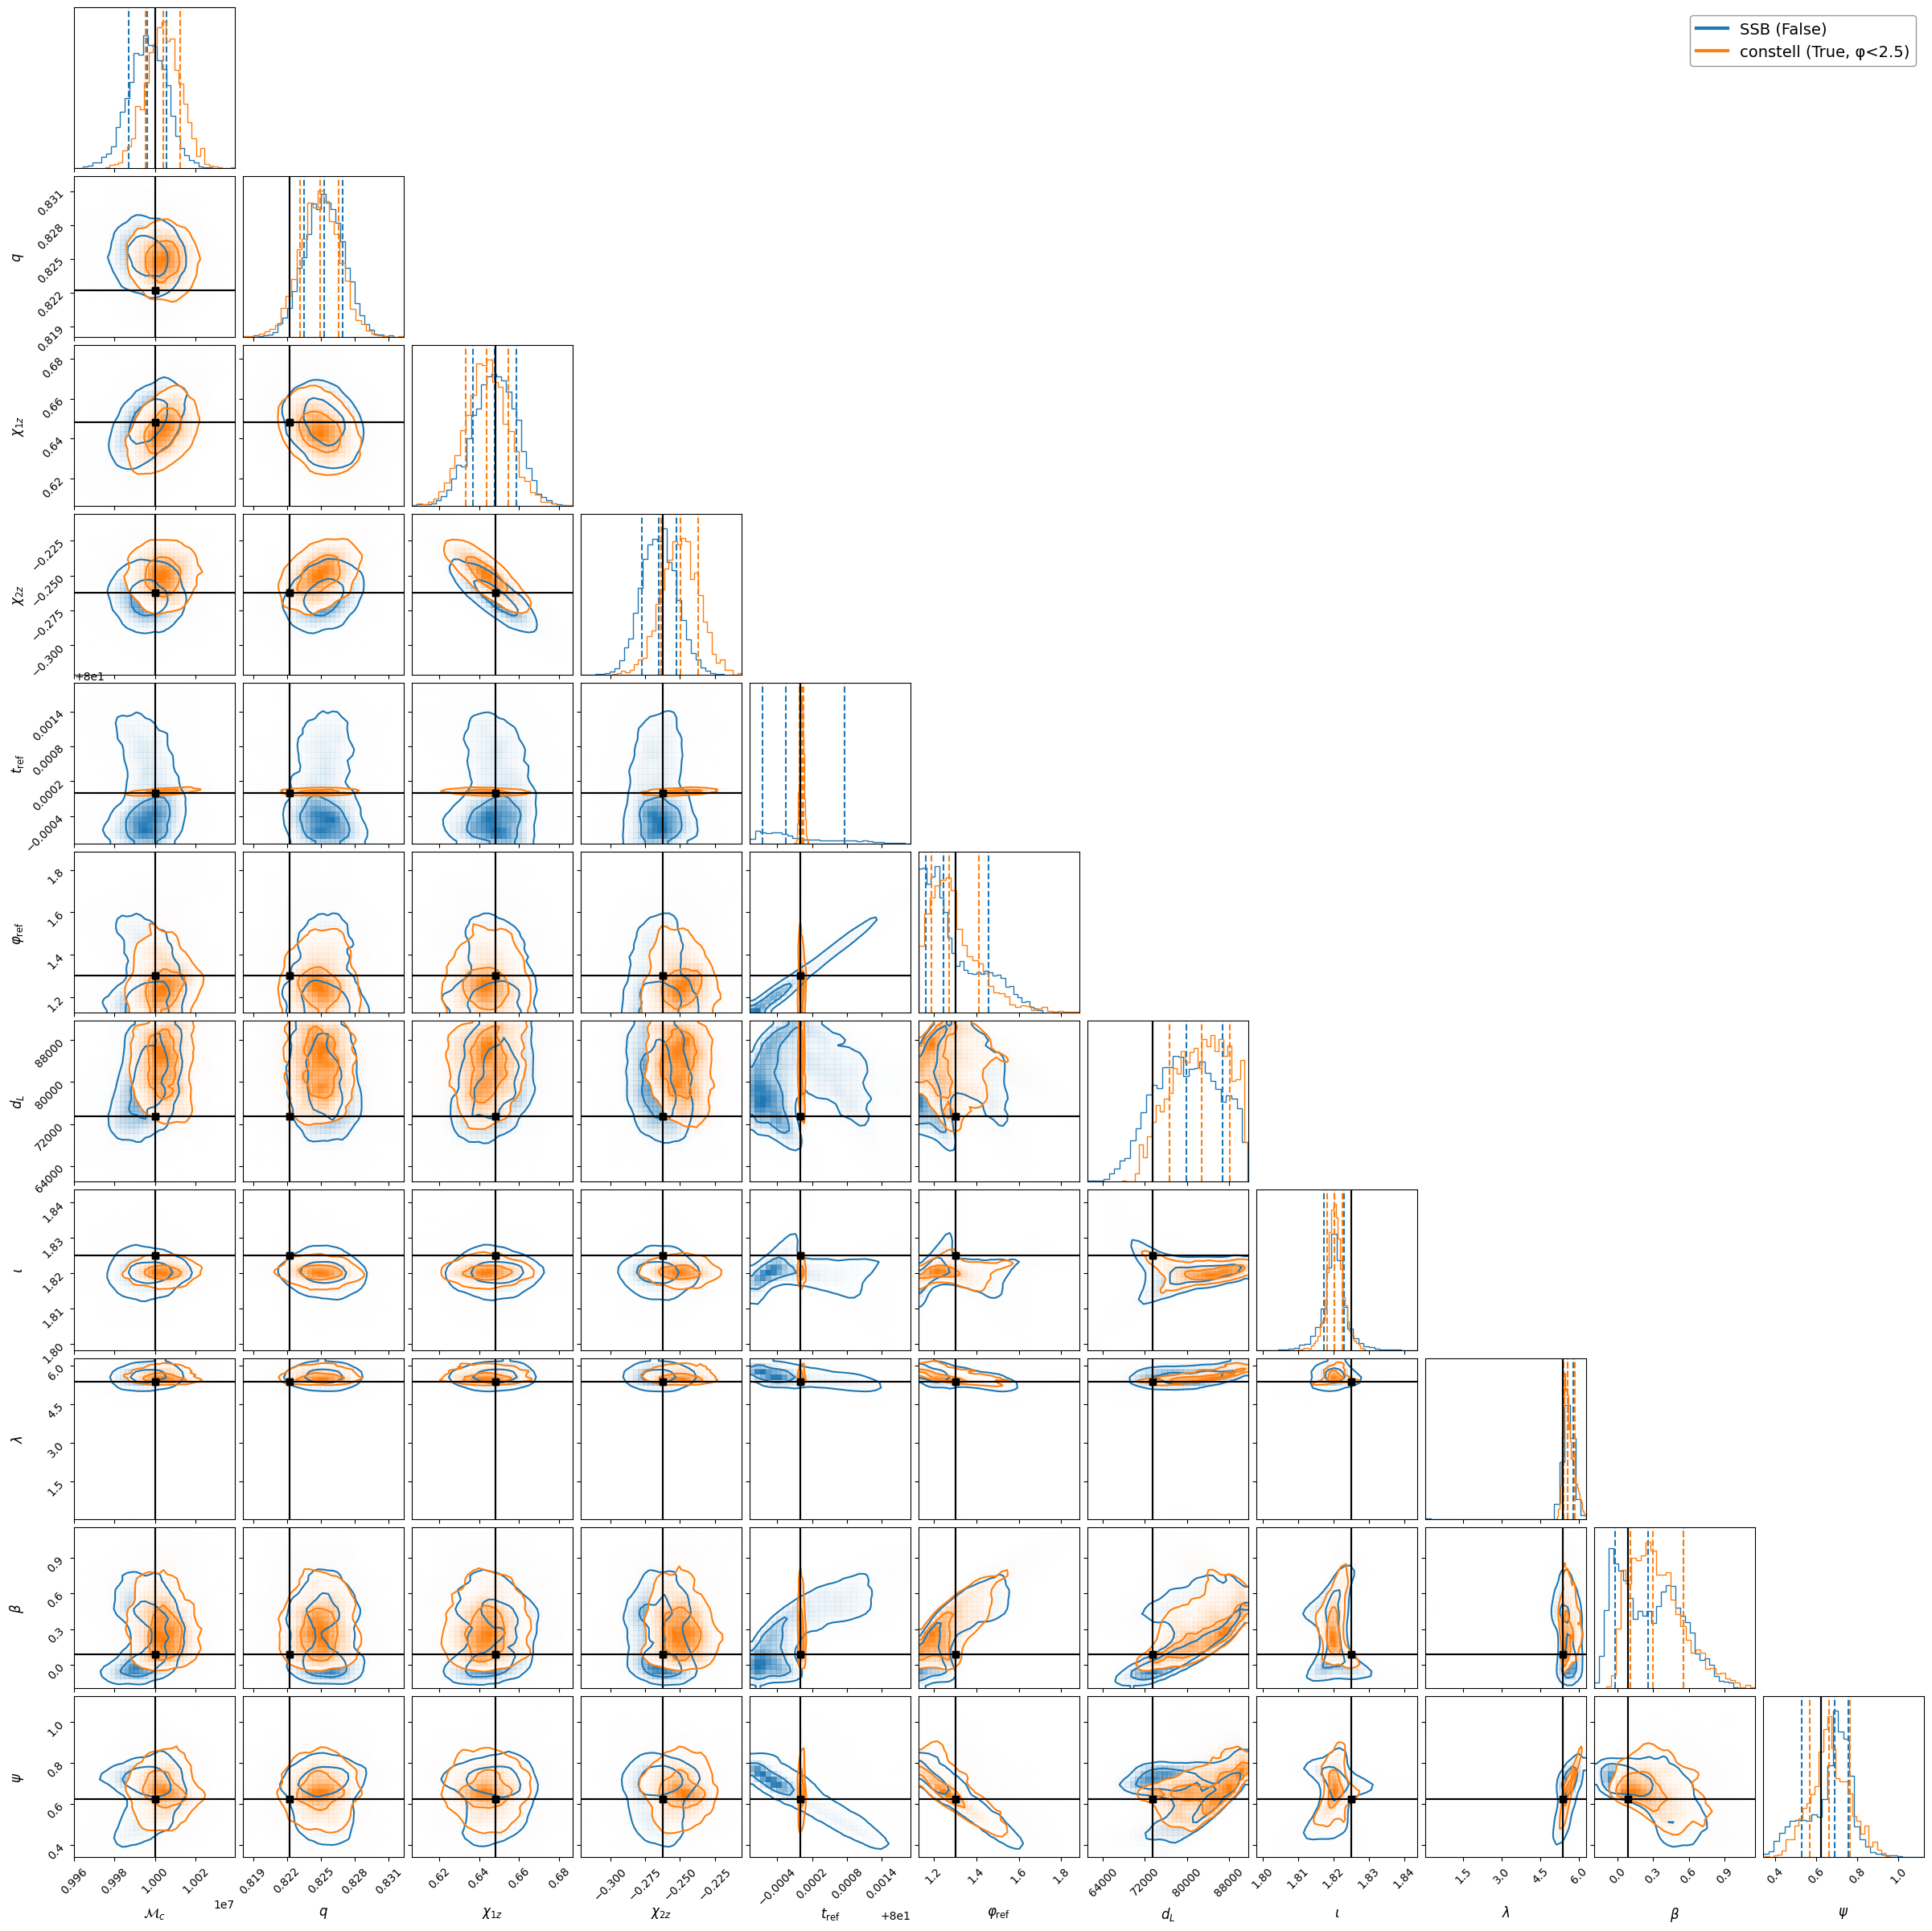

In [ ]:
# ===== 对比 tref_at_constellation=True vs False 的后验 =====
import corner
import bilby

# 读入两个结果
result_ssb  = bilby.result.read_in_result("Samples/mbhb2_nlive800_result.json")
result_cstl = bilby.result.read_in_result("Samples/mbhb2_nlive800_constell_result.json")

# 提取后验样本
post_ssb  = result_ssb.posterior
post_cstl = result_cstl.posterior

# 对 constellation 结果只取 phi_ref < 2.5 的样本（隔离多峰中的主峰）
mask_cstl = post_cstl["reference_phase"] < 2.5
post_cstl_filtered = post_cstl[mask_cstl]
print(f"constellation 样本总数: {len(post_cstl)}, phi_ref < 2.5: {np.sum(mask_cstl)}")

# 共有参数
common_params = [n for n in post_ssb.keys() if n in post_cstl.keys() and n in mbhb_parameters]

truths = [mbhb_parameters[n] for n in common_params]

# LaTeX 标签
latex_labels = {
    "chirp_mass": r"$\mathcal{M}_c$", "mass_ratio": r"$q$",
    "spin_1z": r"$\chi_{1z}$", "spin_2z": r"$\chi_{2z}$",
    "reference_time": r"$t_\mathrm{ref}$", "reference_phase": r"$\varphi_\mathrm{ref}$",
    "luminosity_distance": r"$d_L$", "inclination": r"$\iota$",
    "longitude": r"$\lambda$", "latitude": r"$\beta$", "psi": r"$\psi$",
}
param_labels = [latex_labels.get(n, n) for n in common_params]

# ---- 画叠加 corner plot ----
# 先画 SSB (蓝色)
fig = corner.corner(
    post_ssb[common_params].values,
    labels=param_labels,
    truths=truths,
    truth_color="k",
    color="C0",
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 12},
    hist_kwargs={"density": True},
    plot_density=True,
    plot_datapoints=False,
    fill_contours=False,
    levels=(1 - np.exp(-(np.array([1, 2]) ** 2) / 2.)),
    smooth=0.9,
    bins=30,
)

# 叠加 constellation (橙色, phi_ref < 2.5)
corner.corner(
    post_cstl_filtered[common_params].values,
    fig=fig,
    labels=param_labels,
    truths=truths,
    truth_color="k",
    color="C1",
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 12},
    hist_kwargs={"density": True},
    plot_density=True,
    plot_datapoints=False,
    fill_contours=False,
    levels=(1 - np.exp(-(np.array([1, 2]) ** 2) / 2.)),
    smooth=0.9,
    bins=30,
)

# 图例
from matplotlib.lines import Line2D
axes = np.array(fig.axes).reshape((len(common_params), len(common_params)))
legend_elements = [
    Line2D([0], [0], color="C0", linewidth=3, label="SSB (False)"),
    Line2D([0], [0], color="C1", linewidth=3, label="constell (True, φ<2.5)"),
]
axes[0, -1].legend(
    handles=legend_elements,
    loc="upper right", fontsize=14,
    frameon=True, facecolor="white", edgecolor="grey",
)
# plt.tight_layout()
# plt.show()

# ---- 数值对比 ----
print("\n" + "=" * 95)
print(f"{'Param':<16s} {'True':>12s} {'SSB σ':>10s} {'Cstl σ':>10s} {'σ ratio':>10s}")
print("-" * 95)
for name in common_params:
    s_ssb  = np.std(post_ssb[name])
    s_cstl = np.std(post_cstl_filtered[name])
    ratio  = s_cstl / s_ssb if s_ssb > 0 else np.inf
    print(f"{name:<16s} {mbhb_parameters[name]:>12.4g} {s_ssb:>10.3g} {s_cstl:>10.3g} {ratio:>10.2f}")
print("=" * 95)
print("σ ratio > 1 → constellation 设置下约束更弱")
print("constellation 已过滤 phi_ref < 2.5，仅保留主峰")
